In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import numpy as np


In [2]:
# Configuration
# DATA_ROOT_DIR = '../full_log/dmc/cheetah/vision'  # Path to the data folder outside this notebook
# FOLDER_PATHS = [ 'cls/0.05/s0_nr','cls/0.1/s0_nr','cls/0.5/s0_nr','cls/1.0/s0_nr']  # Specify folder paths relative to DATA_ROOT_DIR
FULL_FOLDER_PATHS = ['../full_log/dmc/cheetah/vision/cls/0.05/s0_nr',
                     '../full_log/dmc/hopper/vision/cls/0.1/s0_f2']
METRICS_FILE_NAME = 'metrics.jsonl'
FIELD_TO_PLOT = 'train/loss/dyn'
FIELD_NAME = 'Dynamics Loss'
# FIELD_TO_PLOT = 'epstats/score'
# FIELD_NAME = 'Evaluation Score'
legend_names=['cheetah', 'hopper']


In [3]:
# a=FOLDER_PATHS[0]
# ks = ['k=' + path.split('/')[1] for path in FOLDER_PATHS]

In [4]:
# Function to load metrics from JSONL files
def load_metrics_from_jsonl(file_path, field):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            entry = json.loads(line)
            if field in entry:
                data.append({
                    'step': entry['step'],
                    field: entry[field]
                })
    return pd.DataFrame(data)

# Initialize a DataFrame to hold all metrics
all_metrics = pd.DataFrame()


In [5]:
# Search for specified folder paths and load metrics
for folder_path in FULL_FOLDER_PATHS:
    # full_folder_path = os.path.join(DATA_ROOT_DIR, folder_path)
    metrics_file_path = os.path.join(folder_path, METRICS_FILE_NAME)
    
    if os.path.exists(metrics_file_path):
        print(f"Loading metrics from: {metrics_file_path}")
        metrics_df = load_metrics_from_jsonl(metrics_file_path, FIELD_TO_PLOT)
        metrics_df['folder'] = folder_path  # Add a column for the folder path
        all_metrics = pd.concat([all_metrics, metrics_df], ignore_index=True)
    else:
        print(f"Metrics file not found: {metrics_file_path}")


Loading metrics from: ../full_log/dmc/cheetah/vision/cls/0.05/s0_nr/metrics.jsonl
Loading metrics from: ../full_log/dmc/hopper/vision/cls/0.1/s0_f2/metrics.jsonl


/tmp/ipykernel_112591/1576554632.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('magma')


NameError: name 'ks' is not defined

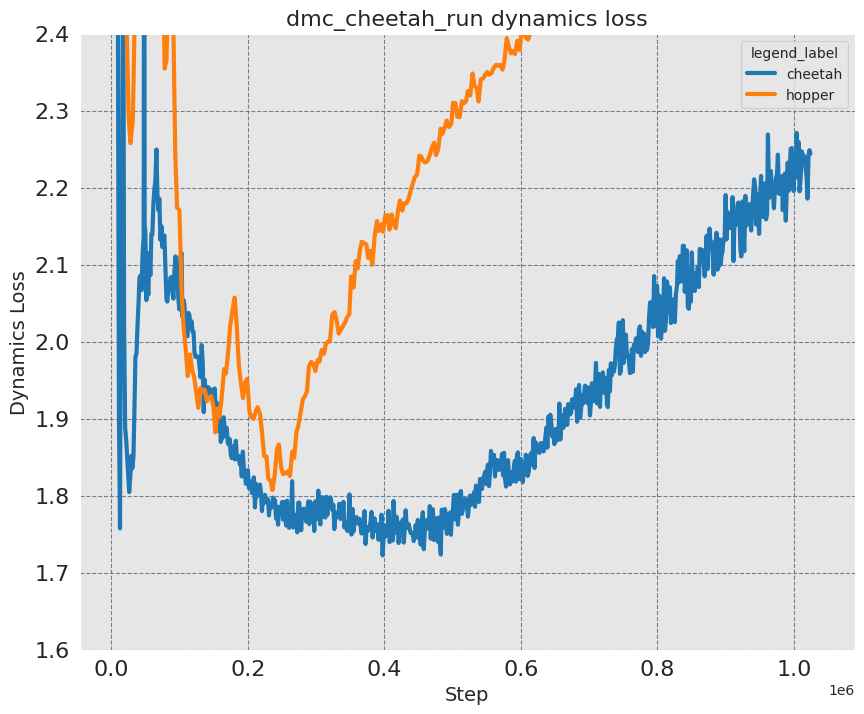

In [ ]:
# Sample colors from a perceptually uniform colormap (e.g., 'magma')
cmap = matplotlib.cm.get_cmap('magma')
colors = [cmap(i) for i in np.linspace(0, 1, 6)]
light_green = matplotlib.colors.to_rgba("green")
colors[0] = light_green  # Replace the first color with light green
color_idxs = [0, 1, 3, 4]
colors = [colors[i] for i in color_idxs]

sns.set_style("darkgrid", {"axes.facecolor": ".9", 'grid.linestyle': '--', 'grid.color': 'slategrey'})

if not all_metrics.empty:
    # Map folder paths to legend names for the legend
    folder_to_legend = dict(zip(FULL_FOLDER_PATHS, legend_names))
    all_metrics['legend_label'] = all_metrics['folder'].map(folder_to_legend)

    plt.figure(figsize=(10, 8))
    ax = sns.lineplot(
        data=all_metrics,
        x='step',
        y=FIELD_TO_PLOT,
        hue='legend_label',  # Use ks values as legend labels
        marker='',
        linewidth=3,
        # palette=colors,
    )
    # plt.title(f'dmc_cheetah_run {FIELD_NAME} Over Steps', fontsize=16)
    plt.title(f'dmc_cheetah_run {FIELD_NAME.lower()}', fontsize=16)
    plt.xlabel('Step', fontsize=14)
    plt.ylabel(FIELD_NAME, fontsize=14)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.ylim(1.6, 2.4)
    plt.legend(fontsize=15, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=len(FULL_FOLDER_PATHS))
    # plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No metrics data found.")

In [ ]:
blue, orange, green, red